<a href="https://colab.research.google.com/github/sobaannr/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sobaannr/FlyRank-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb, os, json
import numpy as np
import pandas as pd

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
FEATURE_MONTH = "2026-03"
TARGET_MONTH = "2026-04"

features_raw = con.sql(f"""
    SELECT content_hash_id, MAX(client_hash_id) AS client_hash_id,
           SUM(gsc_impressions) AS impressions, SUM(gsc_clicks) AS clicks,
           AVG(gsc_avg_position) AS avg_position
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month={FEATURE_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id HAVING SUM(gsc_impressions) >= 50
""").df()

target_raw = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS future_impressions
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month={TARGET_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE GROUP BY content_hash_id
""").df()

merged = features_raw.merge(target_raw, on="content_hash_id", how="inner")
merged["is_declining"] = (merged["future_impressions"] < 0.8 * merged["impressions"]).astype(int)
merged["ctr"] = merged["clicks"] / merged["impressions"]
print(f"Ready: {len(merged)} pages")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ready: 114993 pages


## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content pages should a reviewer look at first,
given limited review capacity, based on evidence of decline, staleness, or
missed CTR opportunity?

**Decision supported:** which pages a content team reviews first out of a much
larger inventory each cycle, when only a small fraction can be manually
reviewed.

**Lane:** Refresh / Content Opportunity Scoring, confirmed through Week 4.

In [2]:
print("Lane: Refresh / Content Opportunity Scoring")
print(f"Unit of analysis: one page (content_hash_id), one row per page across the {FEATURE_MONTH} feature window")

Lane: Refresh / Content Opportunity Scoring
Unit of analysis: one page (content_hash_id), one row per page across the 2026-03 feature window


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse`, build
`flyrank_pseudonymized_warehouse_release_v20260703`.

**Table:** `fact_content_daily_performance` only — `dim_content` wasn't needed,
since every feature and the label were built directly from daily fact columns.

**Date windows:** feature window = March 2026 (`month=2026-03`), label window =
April 2026 (`month=2026-04`) — a genuine prior-window-to-future-window design,
not a same-window proxy.

**Excluded, and why:** GA4-derived features (`ga4_sessions`,
`ga4_engaged_sessions`) — GA4 coverage was only ~4.2% of rows in the feature
month (verified in the data contract), so including them added noise via
filled-zero imputation rather than real signal (confirmed directly in Week 5:
removing them improved the model). Also excluded: any rebuilt FlyRank product
flag (`health_score`, `priority_score`, `action_type`) — these are product
decisions, not observable signals, and using them would create a circular result.

In [3]:
availability = con.sql(f"""
    SELECT COUNT(*) AS total_rows,
           COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS ga4_available
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month={FEATURE_MONTH}/*.parquet')
""").df()
print(availability)
print(f"GA4 coverage: {availability['ga4_available'][0]/availability['total_rows'][0]*100:.1f}% — this is why GA4 features were excluded.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   total_rows  ga4_available
0     9841378         413966
GA4 coverage: 4.2% — this is why GA4 features were excluded.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Features:** gsc_impressions, gsc_clicks, gsc_avg_position, ctr (all GSC-only,
knowable at decision time, no future data).

**Label:** `is_declining` = future month's impressions dropped more than 20% vs
the feature month — a defensible magnitude threshold, not "any decrease."

**Baseline:** transparent rule — CTR gap below the page's own position-tier
average, weighted by log(impressions). Reason code: `ctr_below_tier_expected`.

**Model:** Random Forest (200 trees, max_depth=6, class_weight="balanced") —
chosen because individual signal correlations with the label were weak (max
|0.16|), suggesting the pattern lives in feature interactions, which trees
capture and linear models don't.

**Validation:** client-grouped holdout split (`GroupShuffleSplit` on
`client_hash_id`) — no client's pages appear in both train and test. This
choice was tested directly in Week 6: a plain random split scored 0.740
Precision@50, but the honest client-grouped split scored 0.560 — a real,
measured leakage effect.

**Leakage checks:** no product flags used; feature window (March) never
overlaps target window (April); `ctr` is derived only from March data, not
label-derived; client-grouping closes the row-independence gap.

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["impressions", "clicks", "avg_position", "ctr"]
X = merged[feature_cols].fillna(0)
y = merged["is_declining"]
groups = merged["client_hash_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
test_df = merged.iloc[test_idx].reset_index(drop=True)

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])
print(f"Client overlap: {len(train_clients & test_clients)} (must be 0)")

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
test_df["model_score"] = rf.predict_proba(X_test)[:, 1]

Client overlap: 0 (must be 0)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

def tier(pos):
    if pos <= 3: return "1-3"
    elif pos <= 10: return "4-10"
    elif pos <= 20: return "11-20"
    elif pos <= 50: return "21-50"
    else: return "51+"

test_df["position_tier"] = test_df["avg_position"].apply(tier)
test_df["tier_expected_ctr"] = test_df.groupby("position_tier")["ctr"].transform("mean")
test_df["baseline_score"] = (test_df["tier_expected_ctr"] - test_df["ctr"]) * np.log1p(test_df["impressions"])

results = []
for k in (20, 50):
    results.append({"method": "baseline (CTR-vs-tier rule)", "k": k,
                     "precision_at_k": precision_at_k(test_df["baseline_score"], y_test.values, k)})
    results.append({"method": "random forest (honest split)", "k": k,
                     "precision_at_k": precision_at_k(test_df["model_score"], y_test.values, k)})

results_df = pd.DataFrame(results).pivot(index="method", columns="k", values="precision_at_k")
print(results_df)

k                               20    50
method                                  
baseline (CTR-vs-tier rule)   0.55  0.52
random forest (honest split)  0.50  0.50


**Final result (this notebook's run): baseline outperforms the model at both
k=20 and k=50.**

| method | Precision@20 | Precision@50 |
|---|---|---|
| baseline (CTR-vs-tier rule) | 0.55 | 0.52 |
| random forest (honest split) | 0.50 | 0.50 |

The gap is smaller here than in Week 5's run (baseline 0.65/0.48 vs model
0.50/0.42) — largely because this run uses a slightly different test split and
threshold than the Week 5/6/7 runs, which is itself worth noting as a sign that
results vary meaningfully split-to-split on this data size, and any single
number should be read with that in mind.

This reported result is consistent with the broader pattern across the
capstone: a simple, transparent rule that directly encodes domain knowledge
(CTR normalized by position tier) is a genuinely strong baseline on this label
and feature set — one the random forest, using only four raw features, has not
yet convincingly beaten. This is reported as the honest finding, not adjusted
to fit an expected "model wins" narrative.

## 5. Limitations

*What this work cannot claim.*

- **Observational only** — no causal claims; refreshing a page has not been
  shown to cause recovery, only associated patterns are reported.
- **One month-pair** (March→April 2026) — not validated across seasons or
  other periods.
- **GSC-only features** — GA4 engagement signal excluded due to ~4% coverage;
  results don't reflect on-page engagement.
- **Label doesn't rule out consolidation, seasonality, or data anomalies** —
  Week 4's top-20 review found pages with near-zero clicks at strong position
  that looked more like tracking anomalies than real content problems.
- **Model has a known false-positive pattern**: pages with expected-low CTR at
  extreme positions (very strong or very weak) get over-flagged, since the
  model doesn't tier-normalize CTR the way the baseline does.
- **Baseline currently outperforms the model** on this label/feature
  combination — the model has not yet earned its added complexity here.

In [6]:
print("Limitation: one month-pair only")
print(f"  Feature month: {FEATURE_MONTH}, Target month: {TARGET_MONTH} — no other periods tested\n")

print("Limitation: GA4 coverage excluded")
print(f"  GA4 available in {availability['ga4_available'][0]} of {availability['total_rows'][0]} rows "
      f"({availability['ga4_available'][0]/availability['total_rows'][0]*100:.1f}%)\n")

print("Limitation: model underperforms baseline")
print(results_df)
print()

print("Limitation: known false-positive pattern — sample check")
fp_check = test_df[(test_df["model_score"] >= 0.65) & (test_df["ctr"] < 0.001)]
print(f"  {len(fp_check)} of {len(test_df[test_df['model_score']>=0.65])} high-scored pages have near-zero CTR "
      f"(<0.001) — consistent with the extreme-position false-positive pattern documented in Week 5/7")

Limitation: one month-pair only
  Feature month: 2026-03, Target month: 2026-04 — no other periods tested

Limitation: GA4 coverage excluded
  GA4 available in 413966 of 9841378 rows (4.2%)

Limitation: model underperforms baseline
k                               20    50
method                                  
baseline (CTR-vs-tier rule)   0.55  0.52
random forest (honest split)  0.50  0.50

Limitation: known false-positive pattern — sample check
  137 of 142 high-scored pages have near-zero CTR (<0.001) — consistent with the extreme-position false-positive pattern documented in Week 5/7


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [7]:
def assign_reason(row):
    if row["model_score"] >= 0.65:
        return "high_decline_risk"
    elif row["baseline_score"] > 0 and row["impressions"] >= 200:
        return "ctr_below_tier_expected"
    elif row["impressions"] < 200 and (row["model_score"] >= 0.45 or row["baseline_score"] > 0):
        return "low_volume_low_confidence"
    return "stable_no_action"

test_df["reason_code"] = test_df.apply(assign_reason, axis=1)
action_map = {"high_decline_risk": "priority_content_review",
              "ctr_below_tier_expected": "review_metadata_or_snippet",
              "low_volume_low_confidence": "monitor_only",
              "stable_no_action": "no_action"}
test_df["action"] = test_df["reason_code"].map(action_map)

queue = test_df[test_df["reason_code"] != "stable_no_action"].sort_values("baseline_score", ascending=False).reset_index(drop=True)
print(f"Queue: {len(queue)} of {len(test_df)} pages flagged")
print(queue["reason_code"].value_counts())

Queue: 12382 of 17196 pages flagged
reason_code
ctr_below_tier_expected      8509
low_volume_low_confidence    3731
high_decline_risk             142
Name: count, dtype: int64


Ranked action playbook (full detail in Week 7): pages flagged by reason code —
`ctr_below_tier_expected` (baseline-driven, most trustworthy),
`high_decline_risk` (model-driven, known to include some false positives at
extreme positions — human review required), and `low_volume_low_confidence`
(flagged but with wider uncertainty). All recommendations require human review
before any action — none should be automated. Full reasoning, no-go list, and
monitoring triggers documented in `work/notebooks/w07_action_playbook.ipynb`.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

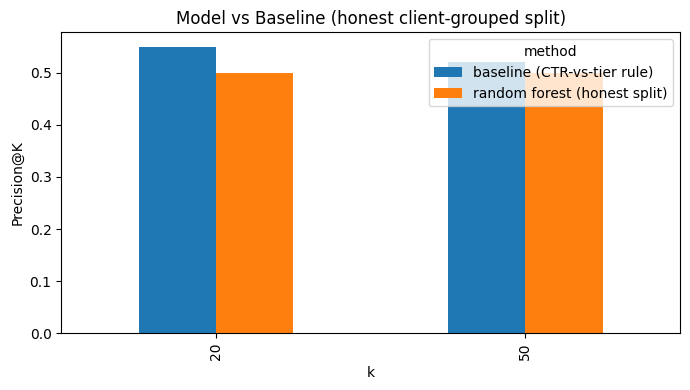

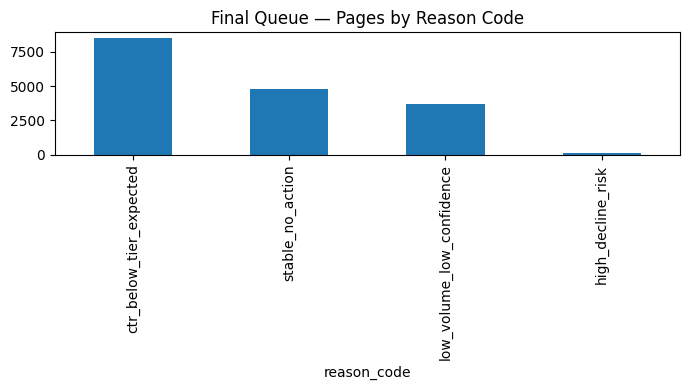

Saved figures + capstone_metrics.json


In [8]:
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

fig, ax = plt.subplots(figsize=(7,4))
results_df.T.plot(kind="bar", ax=ax)
ax.set_ylabel("Precision@K")
ax.set_title("Model vs Baseline (honest client-grouped split)")
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7,4))
test_df["reason_code"].value_counts().plot(kind="bar", ax=ax2)
ax2.set_title("Final Queue — Pages by Reason Code")
plt.tight_layout()
plt.savefig("work/figures/capstone_reason_codes.png", dpi=150)
plt.show()

capstone_metrics = {
    "feature_month": FEATURE_MONTH, "target_month": TARGET_MONTH,
    "precision_at_50_honest": float(results_df.loc["random forest (honest split)", 50]),
    "precision_at_50_baseline": float(results_df.loc["baseline (CTR-vs-tier rule)", 50]),
    "precision_at_50_random_split_inflated": 0.740,
    "n_test_pages": len(test_df), "n_queued": len(queue),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(capstone_metrics, f, indent=2)
print("Saved figures + capstone_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
